# CICIDS 2017 Network Intrusion Detection — LWCE Loss Comparison

PyTorch MLP on CICIDS 2017 (15-class: BENIGN + 14 attack types).  
Comparing 7 loss functions: `ce`, `wce`, `pwce`, `lwce`, `plwce`, `cb`, `focal`.

In [1]:
# Cell 0: Environment + Setup
!pip install -q torch torchvision optuna pandas openpyxl scikit-learn kagglehub

import os, sys, gc, json, warnings, importlib.util, glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import optuna
from optuna.samplers import GridSampler

warnings.filterwarnings('ignore')

# ── GitHub repo ───────────────────────────────────────────────────
REPO_PATH = '/content/imbalanced-data-LWCE'
if not os.path.exists(REPO_PATH):
    print('Cloning...')
    !git clone https://github.com/gseungho/imbalanced-data-LWCE.git {REPO_PATH}

# ── Load classification loss functions ───────────────────────────
get_clf_loss = None
try:
    spec = importlib.util.spec_from_file_location(
        'clf', f'{REPO_PATH}/image_classification/custom_losses.py'
    )
    clf_module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(clf_module)
    get_clf_loss = clf_module.get_clf_loss
    print('✓ Loss functions loaded!')
except Exception as e:
    print(f'Warning: {e}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── Constants ─────────────────────────────────────────────────────
DATASET_NAME       = 'CICIDS2017'
NUM_CLASSES        = 15
BATCH_SIZE         = 512
FINAL_EPOCHS       = 50
PROXY_EPOCHS       = 10
PROXY_SUBSET_RATIO = 0.20
TARGET_TOTAL       = 300_000   # 전체 subset 크기
BENIGN_MAX         = 100_000   # BENIGN 클래스 최대 샘플 수
RESULTS_DIR = '/content/gdrive/MyDrive/imbalanced-data-LWCE/network_data/results/CICIDS2017'
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f'Results dir: {RESULTS_DIR}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 31.8 MB/s eta 0:00:00
Cloning...
Cloning into '/content/imbalanced-data-LWCE'...
remote: Enumerating objects: 609, done.
remote: Counting objects: 100% (609/609), done.
remote: Compressing objects: 100% (442/442), done.
remote: Total 609 (delta 242), reused 432 (delta 144), pack-reused 0 (from 0)
Receiving objects: 100% (609/609), 32.32 MiB | 16.54 MiB/s, done.
Resolving deltas: 100% (242/242), done.
✓ Loss functions loaded!
Device: cuda
Results dir: /content/gdrive/MyDrive/imbalanced-data-LWCE/network_data/results/CICIDS2017


In [2]:
# Cell 1: Load & Preprocess CICIDS 2017
import kagglehub

def load_cicids2017():
    print('Downloading CICIDS 2017...')
    path = kagglehub.dataset_download('chethuhn/network-intrusion-dataset')
    print(f'Dataset path: {path}')

    # 모든 CSV 파일 로드 (요일별 파일 존재)
    csv_files = sorted(glob.glob(f'{path}/**/*.csv', recursive=True))
    if not csv_files:
        csv_files = sorted(glob.glob(f'{path}/*.csv'))
    print(f'CSV files found: {len(csv_files)}')
    for f in csv_files:
        print(f'  {os.path.basename(f)}')

    dfs = []
    for f in csv_files:
        try:
            df = pd.read_csv(f, encoding='utf-8',  low_memory=False)
        except UnicodeDecodeError:
            df = pd.read_csv(f, encoding='latin-1', low_memory=False)
        dfs.append(df)
        print(f'  Loaded {os.path.basename(f)}: {len(df):,} rows')
    df = pd.concat(dfs, axis=0, ignore_index=True)
    print(f'\nTotal rows: {len(df):,}')

    # 레이블 컬럼 정규화 (공백 제거)
    label_col = [c for c in df.columns if 'label' in c.lower()][0]
    df['label'] = df[label_col].astype(str).str.strip()

    # 피처 컬럼 = 레이블 제외 나머지 (숫자형만)
    feature_cols = [c for c in df.columns if c != label_col]
    # inf / -inf → NaN → 제거
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
    before = len(df)
    df = df.dropna(subset=feature_cols)
    print(f'Dropped {before - len(df):,} rows with inf/NaN')

    # 숫자형 피처만 사용
    num_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
    print(f'Numeric features: {len(num_cols)}')

    # ── Stratified Subset (BENIGN 상한 + 전체 300K) ────────────────
    print('\nBuilding stratified subset...')
    unique_labels = df['label'].unique()
    benign_label  = next((l for l in unique_labels
                          if 'benign' in l.lower() or 'normal' in l.lower()),
                         unique_labels[0])
    non_benign_budget = TARGET_TOTAL - BENIGN_MAX
    non_benign_total  = (df['label'] != benign_label).sum()

    idx_list = []
    for lbl in unique_labels:
        mask = df['label'] == lbl
        idx  = df.index[mask].tolist()
        if lbl == benign_label:
            take = min(len(idx), BENIGN_MAX)
        else:
            # 비율 유지 (최소 50개 보장)
            prop = len(idx) / max(non_benign_total, 1)
            take = max(50, min(len(idx), int(prop * non_benign_budget)))
        sampled = np.random.choice(idx, min(take, len(idx)), replace=False)
        idx_list.extend(sampled.tolist())

    df_sub = df.loc[idx_list].reset_index(drop=True)
    print(f'Subset size: {len(df_sub):,}')

    # LabelEncoder
    le = LabelEncoder()
    df_sub['class'] = le.fit_transform(df_sub['label'])
    class_names_enc = le.classes_.tolist()
    num_cls         = len(class_names_enc)
    print(f'Classes ({num_cls}): {class_names_enc}')

    X = df_sub[num_cols].values.astype(np.float32)
    y = df_sub['class'].values.astype(np.int64)

    # Train / Val / Test = 70 : 15 : 15
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=42
    )
    X_val, X_te, y_val, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42
    )

    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_tr)
    X_val  = scaler.transform(X_val)
    X_te   = scaler.transform(X_te)

    class_counts = [int((y_tr == i).sum()) for i in range(num_cls)]
    input_dim    = X_tr.shape[1]

    print(f'\n✓ Loaded: Train={len(X_tr):,}, Val={len(X_val):,}, Test={len(X_te):,}')
    print(f'Input dim: {input_dim}')
    print('\nClass distribution (train):')
    for i, (name, cnt) in enumerate(zip(class_names_enc, class_counts)):
        pct = cnt / sum(class_counts) * 100
        print(f'  {i:2d} {name:35s}: {cnt:6,d} ({pct:.2f}%)')
    ir = max(class_counts) / max(min(c for c in class_counts if c > 0), 1)
    print(f'Imbalance ratio: {ir:.0f}:1')

    return (X_tr, X_val, X_te, y_tr, y_val, y_te,
            class_counts, input_dim, class_names_enc, num_cls)

def make_loaders(X_tr, X_val, X_te, y_tr, y_val, y_te, batch_size):
    def ds(X, y):
        return TensorDataset(torch.tensor(X, dtype=torch.float32),
                             torch.tensor(y, dtype=torch.long))
    train_loader = DataLoader(ds(X_tr,  y_tr),  batch_size=batch_size, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(ds(X_val, y_val), batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader  = DataLoader(ds(X_te,  y_te),  batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader, test_loader

(X_tr, X_val, X_te, y_tr, y_val, y_te,
 class_counts, INPUT_DIM, CLASS_NAMES, NUM_CLASSES) = load_cicids2017()

train_loader, val_loader, test_loader = make_loaders(
    X_tr, X_val, X_te, y_tr, y_val, y_te, BATCH_SIZE
)

Using Colab cache for faster access to the 'network-intrusion-dataset' dataset.
Dataset path: /kaggle/input/network-intrusion-dataset
CSV files found: 8
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  Friday-WorkingHours-Morning.pcap_ISCX.csv
  Monday-WorkingHours.pcap_ISCX.csv
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Tuesday-WorkingHours.pcap_ISCX.csv
  Wednesday-workingHours.pcap_ISCX.csv
  Loaded Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: 225,745 rows
  Loaded Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: 286,467 rows
  Loaded Friday-WorkingHours-Morning.pcap_ISCX.csv: 191,033 rows
  Loaded Monday-WorkingHours.pcap_ISCX.csv: 529,918 rows
  Loaded Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: 288,602 rows
  Loaded Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: 170,366 rows
  Loaded Tuesday-WorkingHours.pcap_

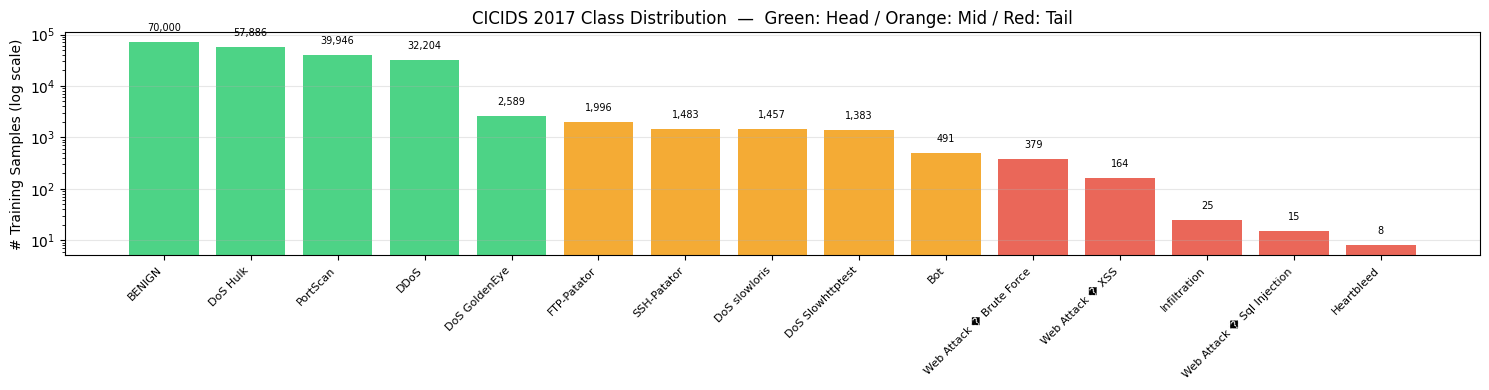

Head (≥2138): 5 classes
Mid  (448–2138): 5 classes
Tail (<448): 5 classes


In [3]:
# Cell 2: Class Distribution Visualization
def visualize_distribution(class_counts, class_names, title, save_path):
    counts = np.array(class_counts)
    order  = np.argsort(counts)[::-1]
    q1, q3 = np.percentile(counts, [33, 66])
    colors = ['#2ecc71' if c >= q3 else '#f39c12' if c >= q1 else '#e74c3c'
              for c in counts[order]]

    fig, ax = plt.subplots(figsize=(max(12, len(class_names)), 4))
    ax.bar(range(len(class_names)), counts[order], color=colors, alpha=0.85)
    ax.set_xticks(range(len(class_names)))
    ax.set_xticklabels([class_names[i] for i in order],
                       rotation=45, ha='right', fontsize=8)
    ax.set_yscale('log')
    ax.set_ylabel('# Training Samples (log scale)')
    ax.set_title(f'{title}  —  Green: Head / Orange: Mid / Red: Tail')
    ax.grid(True, alpha=0.3, axis='y')
    for i, c in enumerate(counts[order]):
        ax.text(i, c * 1.5, f'{c:,}', ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()

    q1_val, q3_val = np.percentile(counts, [33, 66])
    head = sum(1 for c in counts if c >= q3_val)
    mid  = sum(1 for c in counts if q1_val <= c < q3_val)
    tail = sum(1 for c in counts if c < q1_val)
    print(f'Head (≥{q3_val:.0f}): {head} classes')
    print(f'Mid  ({q1_val:.0f}–{q3_val:.0f}): {mid} classes')
    print(f'Tail (<{q1_val:.0f}): {tail} classes')

visualize_distribution(
    class_counts, CLASS_NAMES,
    'CICIDS 2017 Class Distribution',
    f'{RESULTS_DIR}/class_distribution.png'
)

In [4]:
# Cell 3: MLP Model + Evaluation Functions

class MLP(nn.Module):
    """3-hidden-layer MLP with BatchNorm + Dropout."""
    def __init__(self, input_dim, num_classes,
                 hidden_dims=(256, 128, 64), dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def build_mlp():
    return MLP(INPUT_DIM, NUM_CLASSES).to(DEVICE)


def compute_metrics(model, loader, class_counts):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            preds = model(X_b.to(DEVICE)).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_b.numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    labels = list(range(NUM_CLASSES))
    per_f1 = f1_score(y_true, y_pred, average=None, labels=labels, zero_division=0)

    counts = np.array(class_counts)
    q1, q3 = np.percentile(counts, [33, 66])
    head_idx = [i for i in range(NUM_CLASSES) if counts[i] >= q3]
    mid_idx  = [i for i in range(NUM_CLASSES) if q1 <= counts[i] < q3]
    tail_idx = [i for i in range(NUM_CLASSES) if counts[i] < q1]

    return {
        'Accuracy':          float(accuracy_score(y_true, y_pred)),
        'Balanced_Accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'F1_Macro':          float(f1_score(y_true, y_pred, average='macro',    zero_division=0)),
        'F1_Weighted':       float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        'Per_Class_F1':      per_f1.tolist(),
        'Head_F1': float(per_f1[head_idx].mean()) if head_idx else 0.0,
        'Mid_F1':  float(per_f1[mid_idx].mean())  if mid_idx  else 0.0,
        'Tail_F1': float(per_f1[tail_idx].mean()) if tail_idx else 0.0,
    }

print('✓ MLP and evaluation functions defined')

✓ MLP and evaluation functions defined


In [5]:
# Cell 4: train_model() — definition only, not executed here

def train_model(loss_name, class_counts, tr_loader, val_loader,
                alpha=1.0, gamma=2.0, epochs=FINAL_EPOCHS):
    model = build_mlp()

    if get_clf_loss is not None:
        criterion = get_clf_loss(loss_name, class_counts, alpha=alpha, gamma=gamma)
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=5, factor=0.5, min_lr=1e-6
    )

    history      = {'train_loss': [], 'val_F1_Macro': []}
    best_F1_Macro = 0.0
    best_state   = None

    print(f"\n{'='*50}\nTraining {loss_name.upper()} "
          f"(α={alpha:.2f}, γ={gamma:.2f})\n{'='*50}")

    for epoch in range(epochs):
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for X_b, y_b in tr_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            logits   = model(X_b)
            loss     = criterion(logits, y_b)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
            n_batches  += 1

        avg_loss = epoch_loss / max(n_batches, 1)
        history['train_loss'].append(avg_loss)

        metrics  = compute_metrics(model, val_loader, class_counts)
        bal_acc  = metrics['F1_Macro']
        history['val_F1_Macro'].append(bal_acc)
        scheduler.step(bal_acc)

        if bal_acc > best_F1_Macro:
            best_F1_Macro = bal_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
            print(f'Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | '
                  f'BalAcc: {bal_acc:.4f}')

    if best_state is not None:
        model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

    print(f'✓ {loss_name.upper()} best F1-Macro: {best_F1_Macro:.4f}')
    return model, history, best_F1_Macro

print('✓ train_model defined (not executed yet)')

✓ train_model defined (not executed yet)


In [6]:
# Cell 5: Optuna Hyperparameter Search
optuna.logging.set_verbosity(optuna.logging.WARNING)
os.environ['TQDM_DISABLE'] = '1'

def _make_proxy_loader(ratio=PROXY_SUBSET_RATIO):
    n   = int(len(train_loader.dataset) * ratio)
    idx = np.random.choice(len(train_loader.dataset), n, replace=False)
    return DataLoader(Subset(train_loader.dataset, idx),
                     batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

def _cleanup(model=None):
    if model is not None:
        del model
    gc.collect()
    torch.cuda.empty_cache()

print(f'Optuna search (proxy: {PROXY_EPOCHS} epochs, {PROXY_SUBSET_RATIO*100:.0f}% subset)\n')
optuna_best = {}
proxy_loader = _make_proxy_loader()

# ── PWCE: alpha [0.5, 5.0] ────────────────────────────────────────
N_PWCE = 20
study_pwce = optuna.create_study(
    direction='maximize',
    sampler=GridSampler({'alpha': np.linspace(0.5, 5.0, N_PWCE).tolist()})
)
def obj_pwce(trial):
    alpha = trial.suggest_float('alpha', 0.5, 5.0)
    model, _, score = train_model('pwce', class_counts, proxy_loader, val_loader,
                                  alpha=alpha, epochs=PROXY_EPOCHS)
    _cleanup(model)
    return score if score is not None else 0.0
study_pwce.optimize(obj_pwce, n_trials=N_PWCE)
best_pwce = study_pwce.best_params
optuna_best['pwce'] = best_pwce
print(f'✓ PWCE  best: alpha={best_pwce["alpha"]:.2f}  (BalAcc={study_pwce.best_value:.4f})')

# ── PLWCE: alpha [1.0, 10.0] ─────────────────────────────────────
N_PLWCE = 20
study_plwce = optuna.create_study(
    direction='maximize',
    sampler=GridSampler({'alpha': np.linspace(1.0, 10.0, N_PLWCE).tolist()})
)
def obj_plwce(trial):
    alpha = trial.suggest_float('alpha', 1.0, 10.0)
    model, _, score = train_model('plwce', class_counts, proxy_loader, val_loader,
                                  alpha=alpha, epochs=PROXY_EPOCHS)
    _cleanup(model)
    return score if score is not None else 0.0
study_plwce.optimize(obj_plwce, n_trials=N_PLWCE)
best_plwce = study_plwce.best_params
optuna_best['plwce'] = best_plwce
print(f'✓ PLWCE best: alpha={best_plwce["alpha"]:.2f}  (BalAcc={study_plwce.best_value:.4f})')

# ── FOCAL: gamma [0.5, 5.0] ──────────────────────────────────────
N_FOCAL = 20
study_focal = optuna.create_study(
    direction='maximize',
    sampler=GridSampler({'gamma': np.linspace(0.5, 5.0, N_FOCAL).tolist()})
)
def obj_focal(trial):
    gamma = trial.suggest_float('gamma', 0.5, 5.0)
    model, _, score = train_model('focal', class_counts, proxy_loader, val_loader,
                                  gamma=gamma, epochs=PROXY_EPOCHS)
    _cleanup(model)
    return score if score is not None else 0.0
study_focal.optimize(obj_focal, n_trials=N_FOCAL)
best_focal = study_focal.best_params
optuna_best['focal'] = best_focal
print(f'✓ FOCAL best: gamma={best_focal["gamma"]:.2f}  (BalAcc={study_focal.best_value:.4f})')

print(f'\nOptuna Results:\n{json.dumps(optuna_best, indent=2)}')

Optuna search (proxy: 10 epochs, 20% subset)


Training PWCE (α=4.76, γ=2.00)
Epoch 10/10 | Loss: 0.9784 | BalAcc: 0.0847
✓ PWCE best F1-Macro: 0.1264

Training PWCE (α=0.74, γ=2.00)
Epoch 10/10 | Loss: 0.3289 | BalAcc: 0.5996
✓ PWCE best F1-Macro: 0.6127

Training PWCE (α=5.00, γ=2.00)
Epoch 10/10 | Loss: 1.1681 | BalAcc: 0.0530
✓ PWCE best F1-Macro: 0.1335

Training PWCE (α=2.39, γ=2.00)
Epoch 10/10 | Loss: 0.7574 | BalAcc: 0.0677
✓ PWCE best F1-Macro: 0.1168

Training PWCE (α=2.87, γ=2.00)
Epoch 10/10 | Loss: 1.1618 | BalAcc: 0.1231
✓ PWCE best F1-Macro: 0.1240

Training PWCE (α=4.53, γ=2.00)
Epoch 10/10 | Loss: 1.1312 | BalAcc: 0.0707
✓ PWCE best F1-Macro: 0.1035

Training PWCE (α=1.92, γ=2.00)
Epoch 10/10 | Loss: 0.7549 | BalAcc: 0.1650
✓ PWCE best F1-Macro: 0.1796

Training PWCE (α=3.58, γ=2.00)
Epoch 10/10 | Loss: 0.9488 | BalAcc: 0.0740
✓ PWCE best F1-Macro: 0.1053

Training PWCE (α=1.45, γ=2.00)
Epoch 10/10 | Loss: 0.5401 | BalAcc: 0.4407
✓ PWCE best F1-Macro: 0.4407

Training

In [7]:
# Cell 6: Full Experiment
LOSS_CONFIGS  = ['ce', 'wce', 'pwce', 'lwce', 'plwce', 'cb', 'focal']
all_results   = {}
all_histories = {}

print(f"\n{'='*60}")
print(f'FULL EXPERIMENT: {FINAL_EPOCHS} epochs × {len(LOSS_CONFIGS)} loss functions')
print(f"{'='*60}\n")

for loss_name in LOSS_CONFIGS:
    alpha = optuna_best.get(loss_name, {}).get('alpha', 1.0)
    gamma = optuna_best.get('focal', {}).get('gamma', 2.0) if loss_name == 'focal' else 2.0

    model, history, _ = train_model(
        loss_name, class_counts, train_loader, val_loader,
        alpha=alpha, gamma=gamma, epochs=FINAL_EPOCHS
    )
    metrics = compute_metrics(model, test_loader, class_counts)
    all_results[loss_name]   = metrics
    all_histories[loss_name] = history

    print(f'\n{loss_name.upper()} Final:')
    print(f'  Balanced Acc: {metrics["Balanced_Accuracy"]:.4f}')
    print(f'  F1 Macro:     {metrics["F1_Macro"]:.4f}')
    print(f'  Head F1:      {metrics["Head_F1"]:.4f}')
    print(f'  Mid F1:       {metrics["Mid_F1"]:.4f}')
    print(f'  Tail F1:      {metrics["Tail_F1"]:.4f}')
    per_cls = {CLASS_NAMES[i]: f'{v:.3f}' for i, v in enumerate(metrics['Per_Class_F1'])}
    print(f'  Per-class F1: {per_cls}')
    _cleanup(model)

print(f"\n{'='*60}")
print('✓ Full experiment completed!')
print(f"{'='*60}")


FULL EXPERIMENT: 50 epochs × 7 loss functions


Training CE (α=1.00, γ=2.00)
Epoch 10/50 | Loss: 0.0757 | BalAcc: 0.6716
Epoch 20/50 | Loss: 0.0689 | BalAcc: 0.7051
Epoch 30/50 | Loss: 0.0603 | BalAcc: 0.7790
Epoch 40/50 | Loss: 0.0581 | BalAcc: 0.7756
Epoch 50/50 | Loss: 0.0492 | BalAcc: 0.7902
✓ CE best F1-Macro: 0.7987

CE Final:
  Balanced Acc: 0.8148
  F1 Macro:     0.7941
  Head F1:      0.9877
  Mid F1:       0.9396
  Tail F1:      0.4550
  Per-class F1: {'BENIGN': '0.978', 'Bot': '0.806', 'DDoS': '0.991', 'DoS GoldenEye': '0.989', 'DoS Hulk': '0.993', 'DoS Slowhttptest': '0.973', 'DoS slowloris': '0.977', 'FTP-Patator': '0.993', 'Heartbleed': '1.000', 'Infiltration': '0.727', 'PortScan': '0.987', 'SSH-Patator': '0.948', 'Web Attack � Brute Force': '0.548', 'Web Attack � Sql Injection': '0.000', 'Web Attack � XSS': '0.000'}

Training WCE (α=1.00, γ=2.00)
Epoch 10/50 | Loss: 0.3799 | BalAcc: 0.6758
Epoch 20/50 | Loss: 0.3157 | BalAcc: 0.6799
Epoch 30/50 | Loss: 0.2861 | BalAcc: 

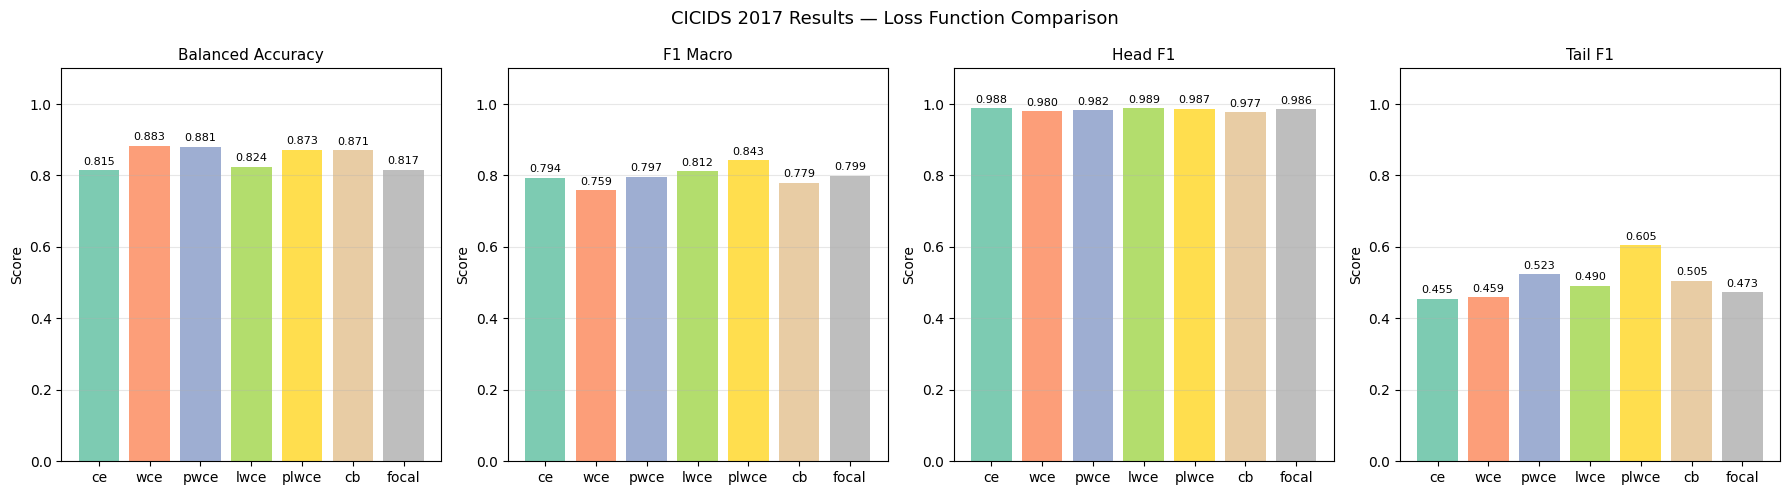

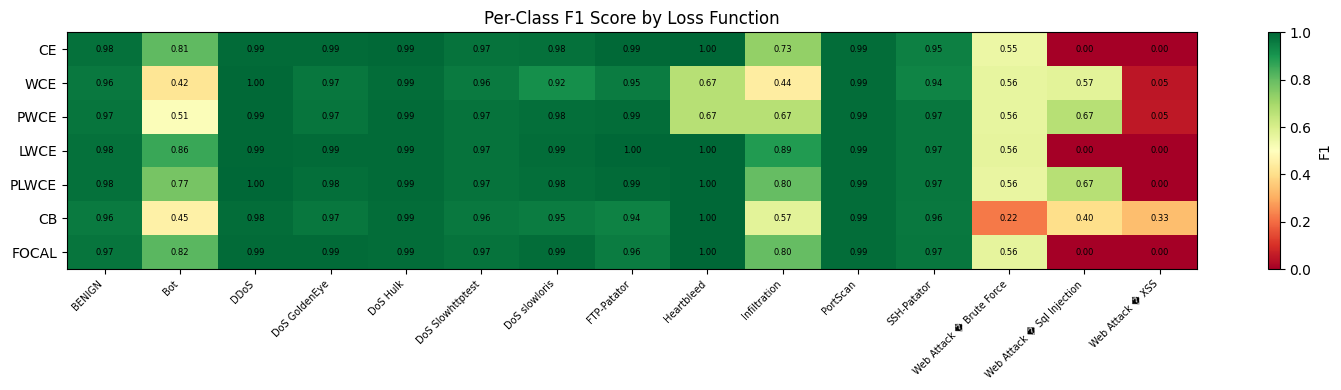

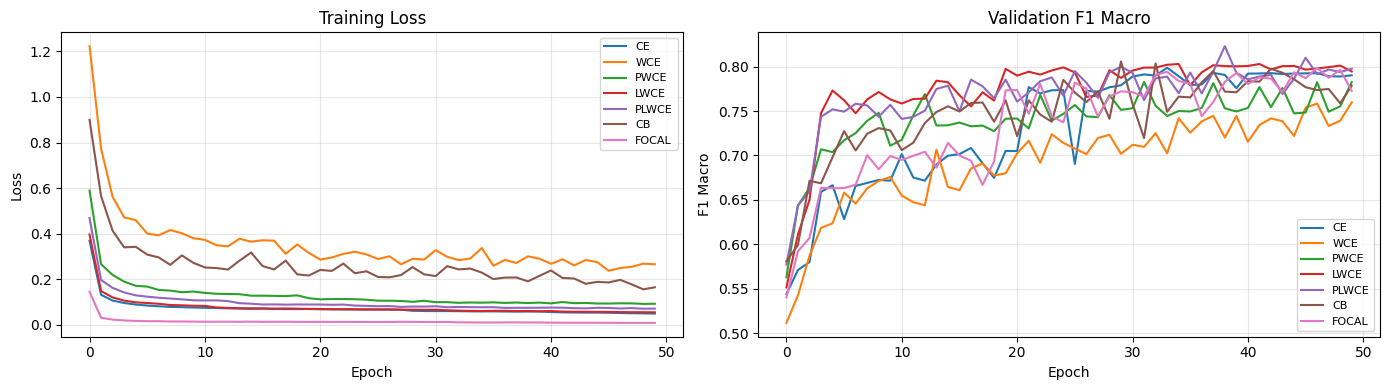

✓ Saved JSON
✓ Saved Excel

EXPERIMENT SUMMARY
 Loss  Balanced_Accuracy  F1_Macro  Head_F1  Tail_F1  Accuracy  F1_Weighted
   ce           0.814770  0.794111 0.987728 0.454978  0.983935     0.983894
  wce           0.882844  0.758781 0.979911 0.458517  0.973604     0.975422
 pwce           0.880823  0.796513 0.982341 0.523064  0.978847     0.979848
 lwce           0.823657  0.811769 0.988565 0.490476  0.984958     0.984904
plwce           0.872632  0.842943 0.986931 0.604706  0.984358     0.984411
   cb           0.870707  0.779403 0.977429 0.505237  0.971626     0.973321
focal           0.816671  0.799302 0.985576 0.472698  0.980647     0.980542


In [9]:
# Cell 7: Visualization + Save Results
loss_names = list(all_results.keys())
bal_accs   = [all_results[ln]['Balanced_Accuracy'] for ln in loss_names]
f1_macros  = [all_results[ln]['F1_Macro']          for ln in loss_names]
head_f1s   = [all_results[ln]['Head_F1']           for ln in loss_names]
tail_f1s   = [all_results[ln]['Tail_F1']           for ln in loss_names]
colors     = plt.cm.Set2(np.linspace(0, 1, len(loss_names)))

# ── Bar chart ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('CICIDS 2017 Results — Loss Function Comparison', fontsize=13)
for ax, vals, title in zip(
    axes,
    [bal_accs, f1_macros, head_f1s, tail_f1s],
    ['Balanced Accuracy', 'F1 Macro', 'Head F1', 'Tail F1']
):
    bars = ax.bar(loss_names, vals, color=colors, alpha=0.85)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.1)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-class F1 heatmap ──────────────────────────────────────────
per_cls_mat = np.array([all_results[ln]['Per_Class_F1'] for ln in loss_names])
fig, ax = plt.subplots(figsize=(max(14, NUM_CLASSES), 4))
im = ax.imshow(per_cls_mat, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(len(loss_names)))
ax.set_yticklabels([ln.upper() for ln in loss_names])
ax.set_title('Per-Class F1 Score by Loss Function')
plt.colorbar(im, ax=ax, label='F1')
for i in range(len(loss_names)):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f'{per_cls_mat[i,j]:.2f}',
                ha='center', va='center', fontsize=6)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/per_class_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Training curves ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ln in loss_names:
    h = all_histories[ln]
    axes[0].plot(h['train_loss'],       label=ln.upper())
    axes[1].plot(h['val_F1_Macro'], label=ln.upper())
for ax, title, ylabel in zip(axes,
    ['Training Loss', 'Validation F1 Macro'], ['Loss', 'F1 Macro']):
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save JSON ─────────────────────────────────────────────────────
results_json = {
    'metadata': {
        'dataset':      'CICIDS 2017',
        'model':        'MLP (256-128-64, BatchNorm, Dropout=0.3)',
        'num_classes':  NUM_CLASSES,
        'class_names':  CLASS_NAMES,
        'final_epochs': FINAL_EPOCHS,
        'batch_size':   BATCH_SIZE,
        'optuna_best':  optuna_best,
        'class_counts': class_counts,
    },
    'results': {ln: all_results[ln] for ln in loss_names}
}
with open(f'{RESULTS_DIR}/cicids2017_results.json', 'w') as f:
    json.dump(results_json, f, indent=2)
print('✓ Saved JSON')

# ── Save Excel ────────────────────────────────────────────────────
summary_df = pd.DataFrame({
    'Loss':              loss_names,
    'Balanced_Accuracy': bal_accs,
    'F1_Macro':          f1_macros,
    'Head_F1':           head_f1s,
    'Tail_F1':           tail_f1s,
    'Accuracy':         [all_results[ln]['Accuracy']   for ln in loss_names],
    'F1_Weighted':      [all_results[ln]['F1_Weighted'] for ln in loss_names],
})
per_class_df = pd.DataFrame(
    {ln: all_results[ln]['Per_Class_F1'] for ln in loss_names},
    index=CLASS_NAMES
)
history_rows = [
    {'loss': ln, 'epoch': ep + 1, 'train_loss': v}
    for ln in loss_names for ep, v in enumerate(all_histories[ln]['train_loss'])
]

with pd.ExcelWriter(f'{RESULTS_DIR}/cicids2017_results.xlsx', engine='openpyxl') as writer:
    summary_df.to_excel(writer,   sheet_name='Summary',          index=False)
    per_class_df.to_excel(writer, sheet_name='Per_Class_F1')
    pd.DataFrame(history_rows).to_excel(writer, sheet_name='Training_History', index=False)
print('✓ Saved Excel')

print(f"\n{'='*60}\nEXPERIMENT SUMMARY\n{'='*60}")
print(summary_df.to_string(index=False))